In [79]:
import pandas as pd

df = pd.read_csv(r"./datasets/Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [80]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [81]:
df.drop(columns="Unnamed: 0", inplace=True, axis=1)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [82]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


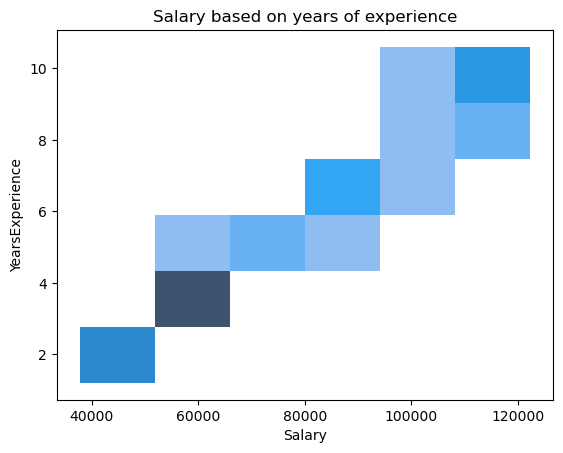

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df, y="YearsExperience", x="Salary")
plt.title("Salary based on years of experience")
plt.show()

In [85]:
inputs = df.drop(columns="Salary").values
inputs[:5]

array([[1.2],
       [1.4],
       [1.6],
       [2.1],
       [2.3]])

In [86]:
target = df.drop(columns="YearsExperience").values
target[:5]

array([[39344.],
       [46206.],
       [37732.],
       [43526.],
       [39892.]])

In [87]:
from sklearn.preprocessing import MinMaxScaler

In [88]:
scaler = MinMaxScaler(feature_range=(0,10))

In [89]:
targets_scalled = scaler.fit_transform(target)
targets_scalled[:5]

array([[0.19040869],
       [1.00094496],
       [0.        ],
       [0.6843846 ],
       [0.2551382 ]])

In [90]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(inputs, targets_scalled, test_size=0.2)

In [91]:
len(x_train), len(x_test)

(24, 6)

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [93]:
model.fit(x_train, y_train)

LinearRegression()

In [94]:
model.score(x_test, y_test)

0.9509259831656353

In [95]:
from sklearn.metrics import r2_score, mean_squared_error

prediction = model.predict(x_test)
r2 = r2_score(y_test, prediction)
mse = mean_squared_error(y_test, prediction)

r2, mse

(0.9509259831656353, 0.631829846886904)

In [96]:
x_test[0], y_test[0]

(array([4.6]), array([2.76163477]))

In [97]:
y_test_pred = model.predict(x_test[0].reshape(1, -1))
y_test_pred

array([[3.63103315]])

In [98]:
y_test_pred_value = scaler.inverse_transform(y_test_pred)
y_test_pred_value

array([[68472.32662235]])